In [62]:
import pandas as pd

# Load the data
df = pd.read_csv("D:/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first few rows of the dataframe
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [63]:
# Check the data types and the number of non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [64]:
# Try to convert 'TotalCharges' to a numeric type and check for any non-numeric values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check if there are any missing values now
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [65]:
# Display the rows with missing 'TotalCharges'
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [66]:
# 用 'MonthCharges' 的值填充 'TotalCharges' 中的缺失值
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)

# 再次检查是否有任何缺失值
missing_values = df.isnull().sum()

In [67]:
# Descriptive statistics for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.798992
std,0.368612,24.559481,30.090047,2266.730170
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [68]:
# Descriptive statistics for categorical columns
df.describe(include=['object'])

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


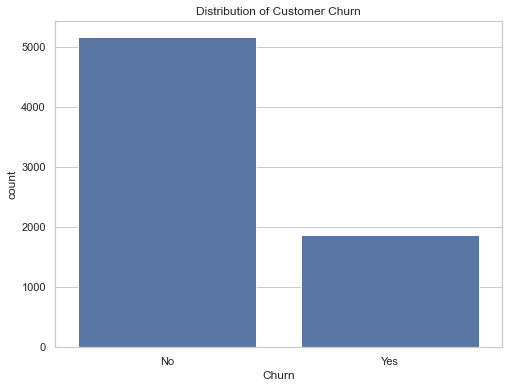

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of seaborn plot
sns.set(style="whitegrid")

# Plot the distribution of 'Churn'
plt.figure(figsize=(8,6))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Customer Churn')
plt.show()

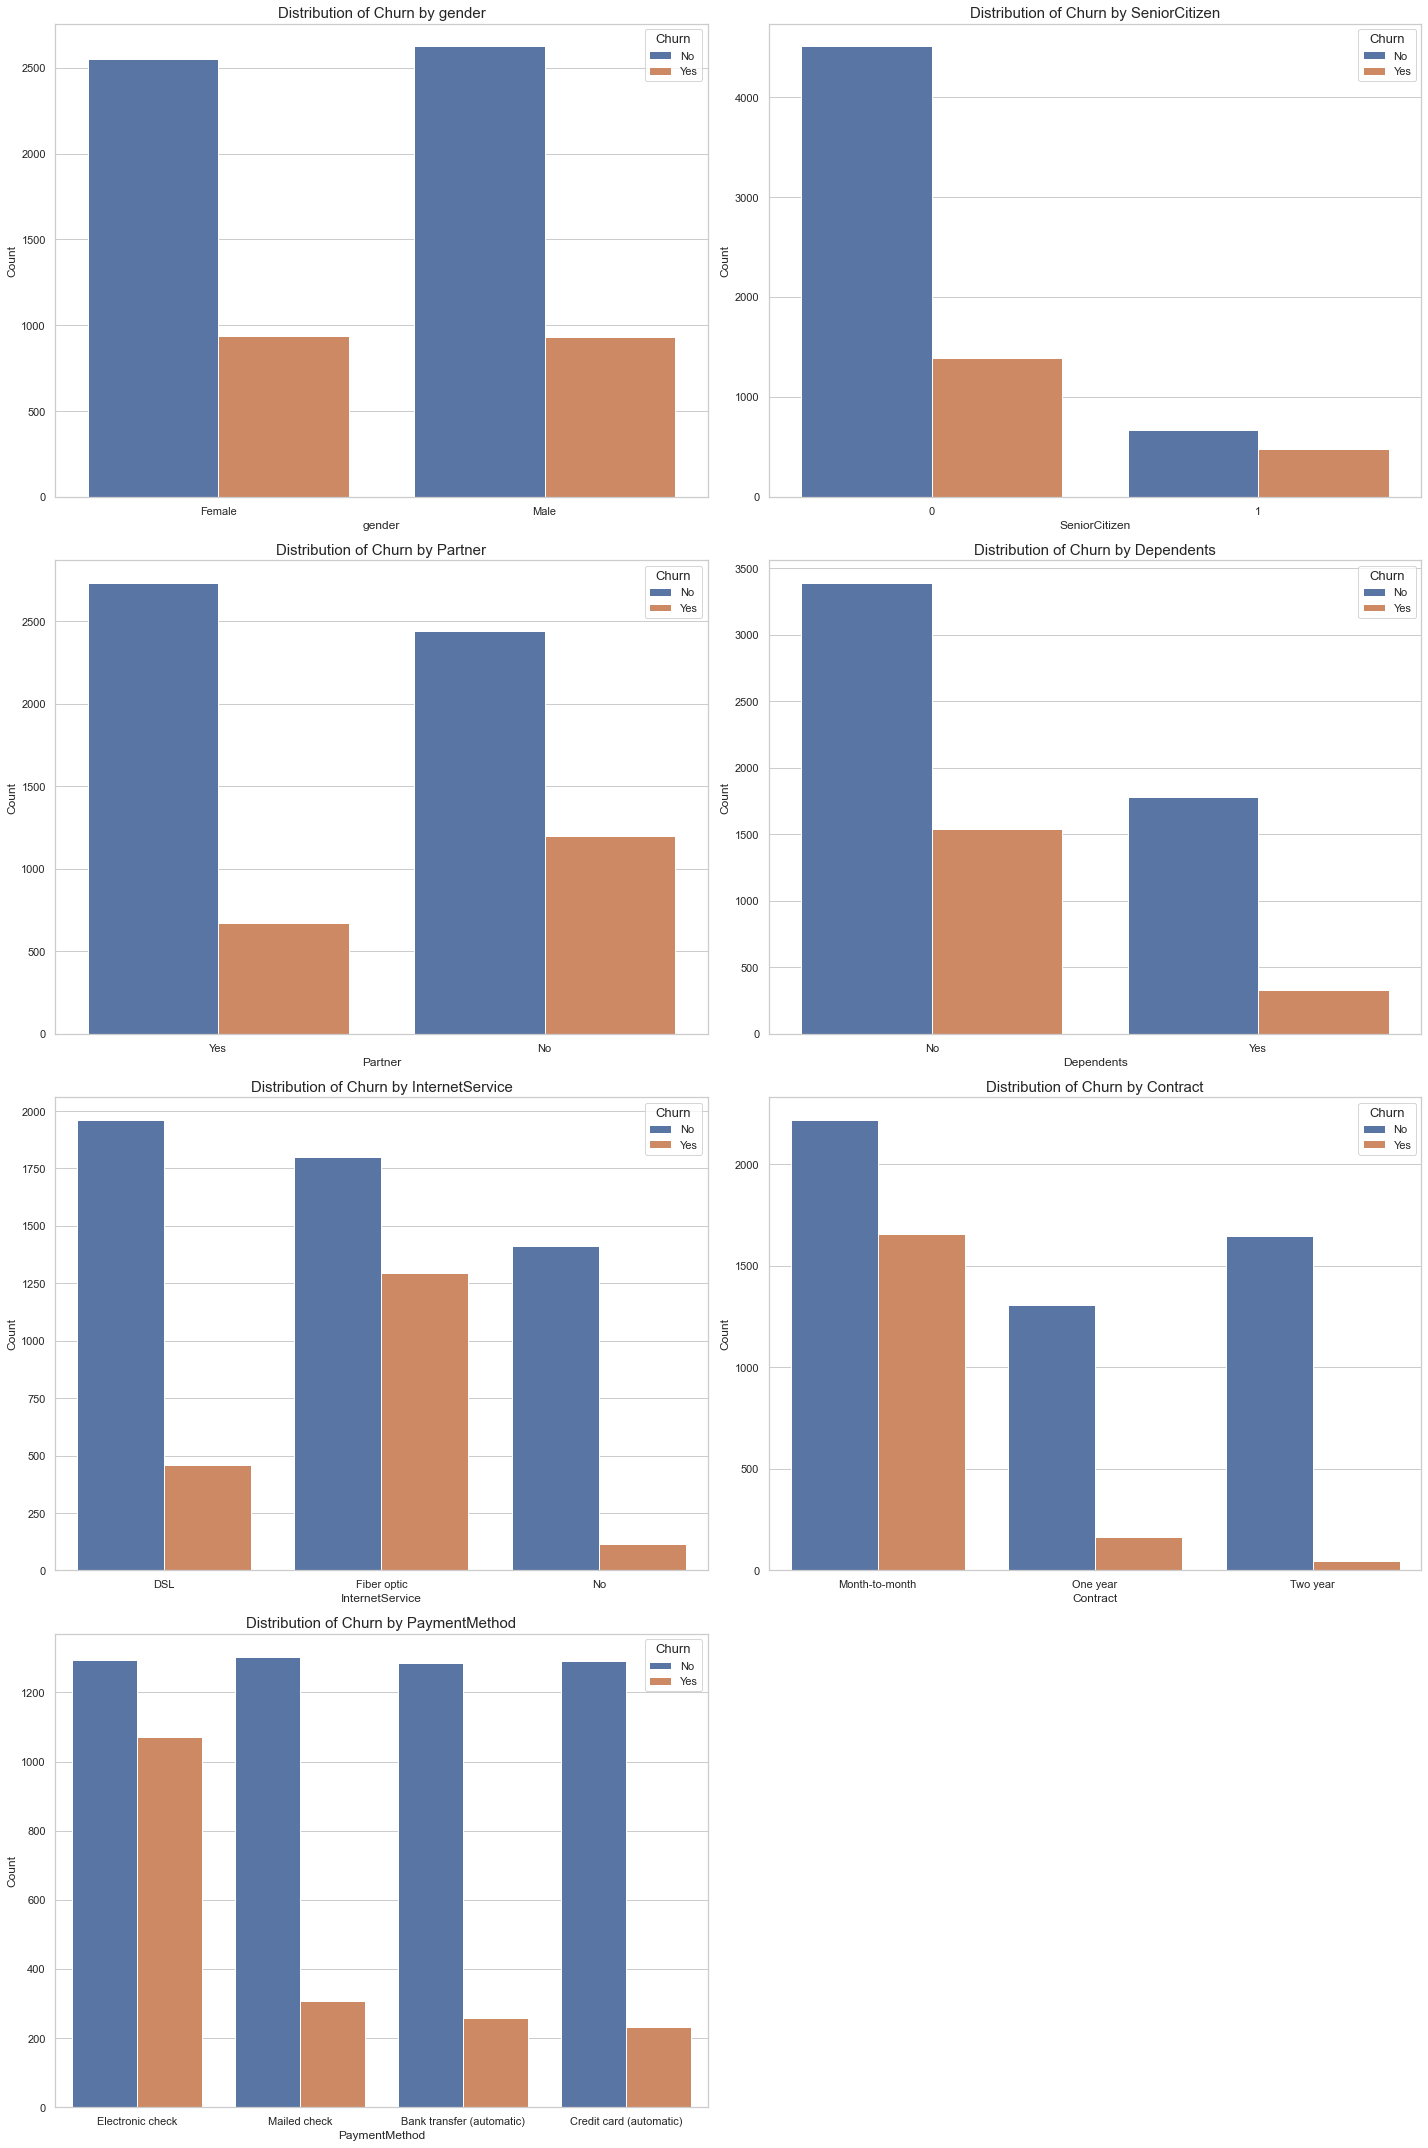

In [70]:
# List of variables to plot
variables = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'Contract', 'PaymentMethod']

# Plot the distribution of each variable with respect to 'Churn'
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 30))
axes = axes.ravel()

for i, var in enumerate(variables):
    sns.countplot(x=var, hue='Churn', data=df, ax=axes[i])
    axes[i].set_title(f'Distribution of Churn by {var}', fontsize=15)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].legend(title='Churn', title_fontsize='13')

# Remove the empty subplot
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

C:\Users\mengyan-zhishang\AppData\Local\Temp\ipykernel_81500\2342367356.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['Churn'] == 'No', var], shade=True, label='No Churn', ax=axes[i])
C:\Users\mengyan-zhishang\AppData\Local\Temp\ipykernel_81500\2342367356.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['Churn'] == 'Yes', var], shade=True, label='Churn', ax=axes[i])
C:\Users\mengyan-zhishang\AppData\Local\Temp\ipykernel_81500\2342367356.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['Churn'] == 'No', var], shade=True, label='No Churn', ax=axes[i])
C:\Users\mengyan-zhishang\AppD

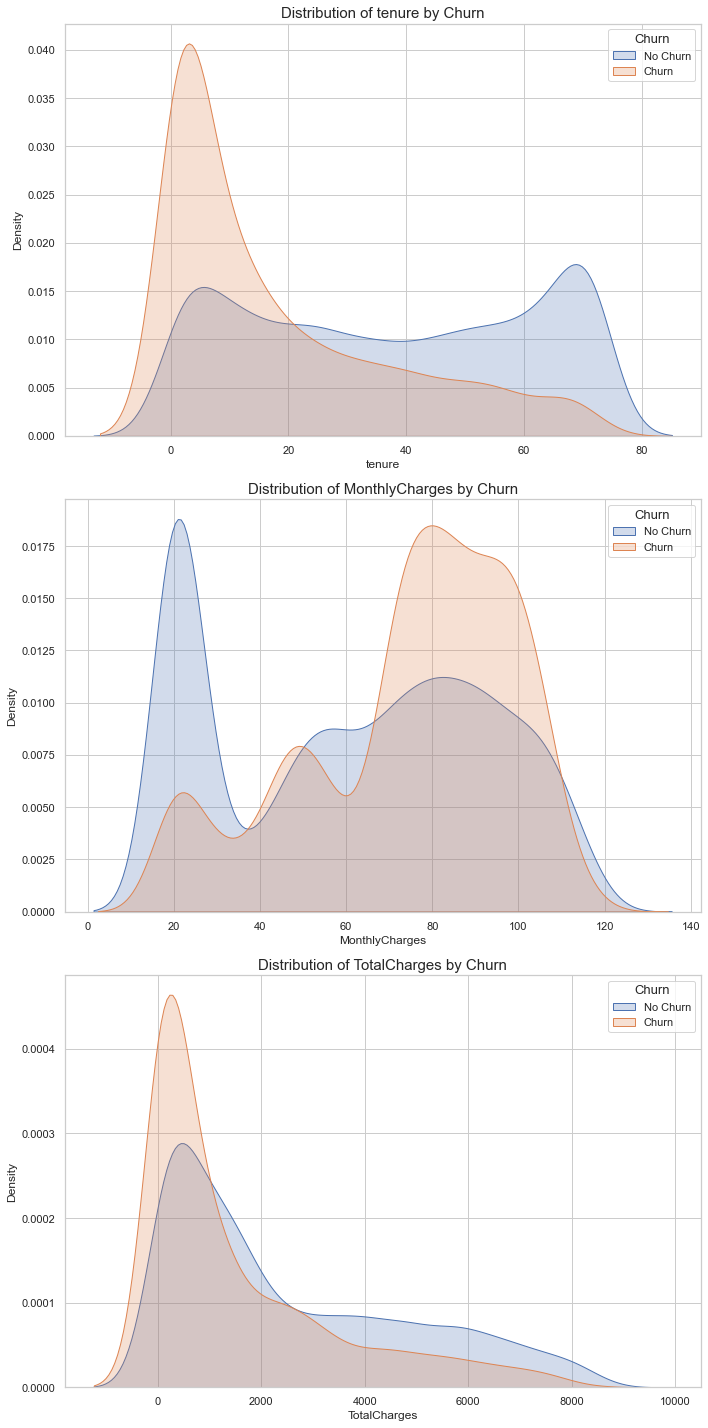

In [71]:
# List of numerical variables to plot
numerical_variables = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Plot the distribution of each variable for churned and non-churned customers
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 20))

for i, var in enumerate(numerical_variables):
    sns.kdeplot(df.loc[df['Churn'] == 'No', var], shade=True, label='No Churn', ax=axes[i])
    sns.kdeplot(df.loc[df['Churn'] == 'Yes', var], shade=True, label='Churn', ax=axes[i])
    axes[i].set_title(f'Distribution of {var} by Churn', fontsize=15)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel('Density', fontsize=12)
    axes[i].legend(title='Churn', title_fontsize='13')

plt.tight_layout()
plt.show()

In [72]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataframe for encoding
df_encoded = df.copy()

# Initialize a LabelEncoder
le = LabelEncoder()

# List of categorical variables to encode
categorical_variables = ['gender', 'Partner', 'Dependents', 'InternetService', 'Contract', 'PaymentMethod', 'Churn']

# Encode the categorical variables
for var in categorical_variables:
    df_encoded[var] = le.fit_transform(df[var])

# Check the first few rows of the encoded dataframe
df_encoded.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,No,No phone service,0,No,...,No,No,No,No,0,Yes,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,Yes,No,0,Yes,...,Yes,No,No,No,1,No,3,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,Yes,No,0,Yes,...,No,No,No,No,0,Yes,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,No,No phone service,0,Yes,...,Yes,Yes,No,No,1,No,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,Yes,No,1,No,...,No,No,No,No,0,Yes,2,70.70,151.65,1


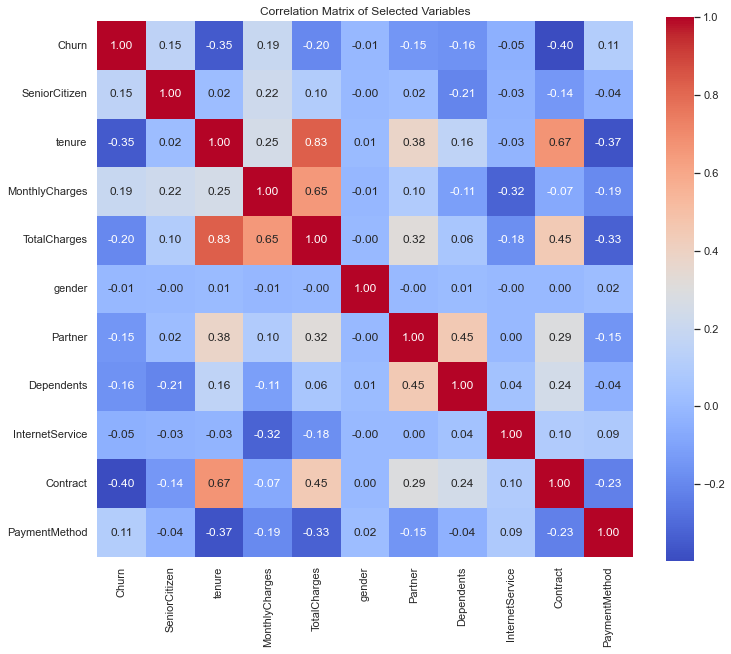

In [73]:
# List of variables for the correlation matrix
variables = ['Churn', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender', 
             'Partner', 'Dependents', 'InternetService', 'Contract', 'PaymentMethod']

# Calculate the correlation matrix
corr_matrix = df_encoded[variables].corr()

# Plot a heatmap of the correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Correlation Matrix of Selected Variables')
plt.show()

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define the features and target
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

# Define the numerical and categorical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Define the preprocessing steps
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first')

# Combine the preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# Fit and transform the data
X_preprocessed = preprocessor.fit_transform(X)

# Encode the target variable
y_encoded = le.fit_transform(y)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y_encoded, test_size=0.2, random_state=0)

X_train.shape, X_test.shape

((5634, 30), (1409, 30))

In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize a Random Forest classifier
rf = RandomForestClassifier(random_state=0)

# Train the model
rf.fit(X_train, y_train)

# Predict the test data
y_pred = rf.predict(X_test)

# Calculate the performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)

accuracy, precision, recall, f1, cm

(0.7806955287437899,
 0.604982206405694,
 0.46195652173913043,
 0.5238828967642527,
 array([[930, 111],
        [198, 170]], dtype=int64))

In [76]:
# Get the feature names after one-hot encoding
onehot_features = list(preprocessor.named_transformers_['cat'].get_feature_names(input_features=categorical_features))
all_features = list(numerical_features) + onehot_features

# Get the feature importances
importances = rf.feature_importances_

# Create a dataframe of features and importances
feature_importances = pd.DataFrame({'Feature': all_features, 'Importance': importances})

# Sort the dataframe by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Display the dataframe
feature_importances

C:\Users\mengyan-zhishang\anaconda3\envs\tensorflow\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


,Feature,Importance
3,TotalCharges,0.195318
1,tenure,0.178113
2,MonthlyCharges,0.163662
28,PaymentMethod_Electronic check,0.041136
10,InternetService_Fiber optic,0.041122
4,gender_Male,0.028195
25,Contract_Two year,0.026951
13,OnlineSecurity_Yes,0.024713
26,PaperlessBilling_Yes,0.024521
5,Partner_Yes,0.023340


In [77]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Initialize a SelectKBest object
selector = SelectKBest(score_func=mutual_info_classif, k=10)

# Fit and transform the data
X_new = selector.fit_transform(X_preprocessed, y_encoded)

# Get the selected feature names
selected_features = [feature for (feature, selected) in zip(all_features, selector.get_support()) if selected]

selected_features


['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'InternetService_Fiber optic',
 'OnlineBackup_No internet service',
 'TechSupport_No internet service',
 'StreamingTV_No internet service',
 'StreamingMovies_No internet service',
 'Contract_Two year',
 'PaymentMethod_Electronic check']

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# Initialize the models
rf = RandomForestClassifier(random_state=0)
lr = LogisticRegression(random_state=0)
svc = SVC(random_state=0)
gbc = GradientBoostingClassifier(random_state=0)

models = [rf, lr, svc, gbc]
model_names = ['Random Forest', 'Logistic Regression', 'Support Vector Machine', 'Gradient Boosting']

# Select the top 10 features from the training and test sets
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Train and evaluate the models
for model, name in zip(models, model_names):
    # Train the model
    model.fit(X_train_selected, y_train)
    
    # Predict the test data
    y_pred = model.predict(X_test_selected)
    
    # Print the classification report
    print(f"{name}:\n")
    print(classification_report(y_test, y_pred))

Random Forest:

              precision    recall  f1-score   support

           0       0.81      0.86      0.83      1041
           1       0.52      0.45      0.48       368

    accuracy                           0.75      1409
   macro avg       0.67      0.65      0.66      1409
weighted avg       0.74      0.75      0.74      1409

Logistic Regression:

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1041
           1       0.63      0.49      0.55       368

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Support Vector Machine:

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1041
           1       0.65      0.45      0.53       368

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted av

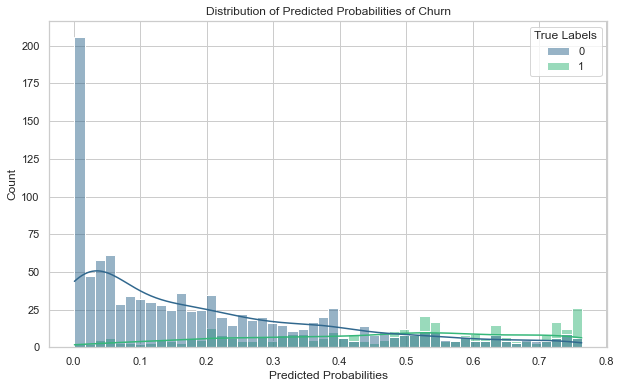

In [79]:
# Calculate the predicted probabilities of churn
y_pred_prob = lr.predict_proba(X_test_selected)[:, 1]

# Create a dataframe of true labels and predicted probabilities
prob_df = pd.DataFrame({'True Labels': y_test, 'Predicted Probabilities': y_pred_prob})

# Plot the distribution of predicted probabilities for churned and non-churned customers
plt.figure(figsize=(10,6))
sns.histplot(data=prob_df, x='Predicted Probabilities', hue='True Labels', bins=50, kde=True, palette='viridis')
plt.title('Distribution of Predicted Probabilities of Churn')
plt.show()


In [80]:
# 定义一个空列表
last_10_preds = []

# 遍历每个模型
for model, name in zip(models, model_names):
    # 训练模型
    model.fit(X_train_selected, y_train)
    
    # 预测测试数据
    y_pred = model.predict(X_test_selected)
    

    # 获取最后 10 个预测结果
    last_10 = y_pred[-10:]
    
    # 添加到列表中
    last_10_preds.append(last_10)

# 打印列表中的内容
print(last_10_preds)

# 打印最后 10 个真实结果
print(y_test[-10:])


[array([0, 0, 0, 0, 1, 1, 1, 0, 0, 1]), array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0]), array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0]), array([0, 0, 0, 0, 1, 1, 1, 0, 0, 1])]
[0 1 0 0 0 1 1 1 0 0]


array([[-0.43991649, -0.91096131,  1.19111984, -0.5380377 ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  1.        ,  0.        ],
       [-0.43991649, -0.30015585, -1.48603513, -0.7763206 ,  0.        ,
         1.        ,  1.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ],
       [-0.43991649,  1.2064976 , -1.36638574, -0.38073393,  0.        ,
         1.        ,  0.        ,  1.        ,  0

In [21]:
customerID=data_cp['customerID']
data_cp.drop(['customerID'],axis=1, inplace=True)

In [22]:
cateCols = [c for c in data_cp.columns if data_cp[c].dtype == 'object' or c == 'SeniorCitizen']
dfCate = data_cp[cateCols].copy()
dfCate.head(3)


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


In [23]:
for col in cateCols:
    if dfCate[col].nunique() == 2:
        dfCate[col] = pd.factorize(dfCate[col])[0]
    else:
        dfCate = pd.get_dummies(dfCate, columns=[col])
dfCate['tenure']=data_cp[['tenure']]
dfCate['MonthlyCharges']=data_cp[['MonthlyCharges']]
dfCate['TotalCharges']=data_cp[['TotalCharges']]

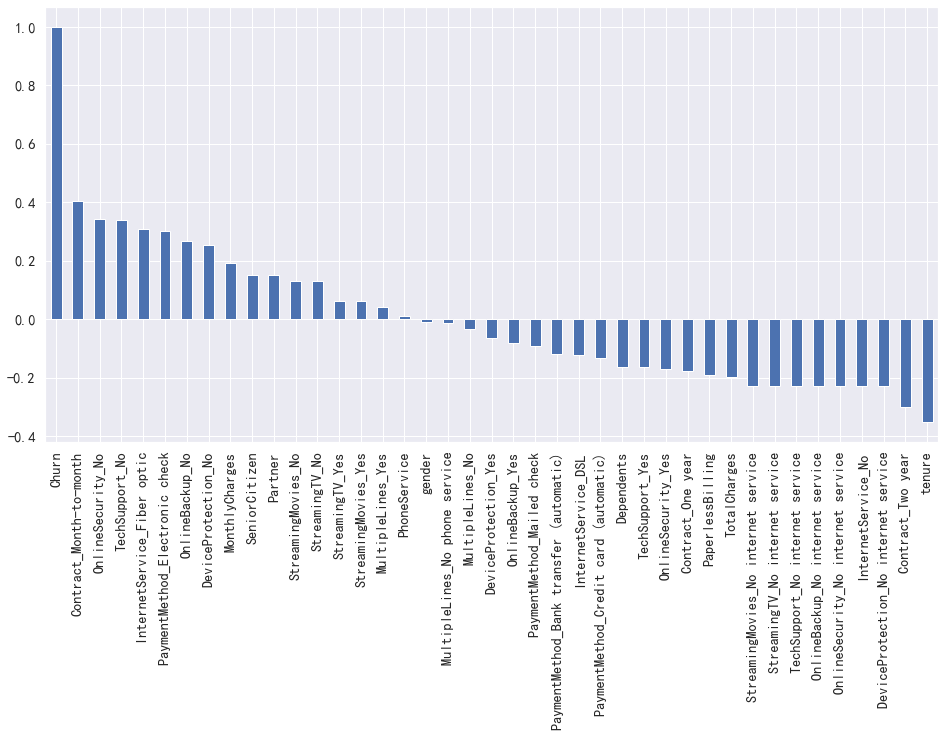

In [24]:
plt.figure(figsize=(16,8))
dfCate.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')
plt.show()

In [25]:
data_cpvar=data_cp.iloc[:,2:20]
data_cpvar.drop('PhoneService',axis=1,inplace=True)

#提取ID
data_cp_id=data_cp['Churn']
print(data_cpvar.head())


  Partner Dependents  tenure     MultipleLines InternetService OnlineSecurity  \
0     Yes         No       1  No phone service             DSL             No   
1      No         No      34                No             DSL            Yes   
2      No         No       2                No             DSL            Yes   
3      No         No      45  No phone service             DSL            Yes   
4      No         No       2                No     Fiber optic             No   

  OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies  \
0          Yes               No          No          No              No   
1           No              Yes          No          No              No   
2          Yes               No          No          No              No   
3           No              Yes         Yes          No              No   
4           No               No          No          No              No   

         Contract PaperlessBilling              PaymentMethod 

In [26]:

#模型特征构建
data_model = data_cp.copy()
# 合并特征，business1,2,3

data_model['business1'] = data_model.apply(lambda x:1 if (x.OnlineSecurity =='Yes')&(x.TechSupport == 'Yes') else 0 , axis =1)
data_model['business2'] = data_model.apply(lambda x:1 if (x.DeviceProtection =='Yes')&(x.OnlineBackup == 'Yes') else 0   , axis =1)
data_model['business3'] = data_model.apply(lambda x:1 if (x.StreamingTV =='Yes')&(x.StreamingMovies == 'Yes') else 0   , axis =1)

#对tenure、MonthlyCharges 分桶 根据之前分析 MonthlyCharges 分为4个bins,tenure分为3个bins
data_model['MonthlyCharges_bins'] = pd.cut(data_model['MonthlyCharges'],4)
data_model['tenure_bins'] = pd.cut(data_model['tenure'],3)

#独热编码
data_model['SeniorCitizen'] = data_model['SeniorCitizen'].astype(str)

data_model['alone'] = data_model.apply(lambda x:1 if (x.Partner == 'No')&(x.Dependents == 'No') else 0 , axis = 1)
# data_model['alone'] = data_model['alone'].astype(str)
data_model['business1'] = data_model['business1'].astype(str)
data_model['business2'] = data_model['business2'].astype(str)
data_model['business3'] = data_model['business3'].astype(str)
data_model['MultipleLines'] = data_model['MultipleLines'].apply(lambda x :1 if x=='Yes' else 0)
data_model['MultipleLines'] = data_model['MultipleLines'].astype(str)
x = data_model[['Partner','Dependents','alone','Contract','business1','business2','business3','tenure_bins','MonthlyCharges_bins','PaymentMethod','PaperlessBilling']]
target = data_model['Churn'].apply(lambda x:1 if x =='Yes' else 0 )
x = pd.get_dummies(x)

In [36]:
# 划分数据集，用留出法取4/5的数据用于训练，1/5用于检测
from sklearn.model_selection import train_test_split

x_train, x_test, target_train, target_test = train_test_split(x, target, test_size=0.25, random_state=0)
# 构建模型
# 导入算法模块
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, recall_score
from sklearn.metrics import make_scorer, accuracy_score

#将需要使用的模型及需要网格搜索的参数提前设定
# LogisticRegression
LR_clf = LogisticRegression(max_iter= 3000)
param_dict1 = {
    'penalty' : ['l1','l2'],
    'C':[5,10,12,14],
    'class_weight':['balanced']
    
}
# DecisionTreeClassifier
DT_clf = DecisionTreeClassifier(random_state=0)
param_dict2 = {
    'max_depth':[4,5,6],
    'min_samples_leaf' : [1,2,3],
    'class_weight':['balanced']
}
# MultinomialNB
NBC_clf = MultinomialNB()
para_dict3 ={
    'alpha' : [1.0]
}
# SVC
SVC_clf = SVC()
param_dict4 = {
    'C':[1,2,3,4],
    'kernel':['rbf','linear','poly'],
    'class_weight':['balanced']
}
# RandomForestClassifier
RF_clf = RandomForestClassifier()
param_dict5 = {
    'n_estimators' :range(80,200,4),
    'max_features':[2,4,6,8],
    'class_weight':['balanced']
}
# KNeighborsClassifier
KNN_clf = KNeighborsClassifier()
param_dict6 = {
    'n_neighbors':[5]
}

Model_list = [LR_clf,DT_clf,NBC_clf,SVC_clf,RF_clf,KNN_clf]
param_list = [param_dict1,param_dict2,para_dict3,param_dict4,param_dict5,param_dict6]
estimator = []
params = []
score = []
scoring = make_scorer(recall_score)
for i in range(6):
    clf_R = Model_list[i]
    parameters = param_list[i]
    grid = GridSearchCV(clf_R,parameters,cv = 5,scoring= scoring,n_jobs = -1)
    grid.fit(x_train,target_train)
    temp = grid.best_estimator_
    estimator.append(temp)
    temp = grid.best_params_
    params.append(temp)
    temp = grid.best_score_
    score.append(temp)
    
for i in range(6):
    model = estimator[i]
    model.fit(x_train,target_train)
    y_predict = model.predict(x_test)
    recall = recall_score(y_true=target_test,y_pred=y_predict)
    print('算法模型：',estimator[i],'\n')
    print('模型参数：',params[i],'\n')
    print('模型的召回率：',recall,'\n')
    print('模型测试精确率：',score[i],'\n')
    print('-'*20)

算法模型： LogisticRegression(C=5, class_weight='balanced', max_iter=3000) 

模型参数： {'C': 5, 'class_weight': 'balanced', 'penalty': 'l2'} 

模型的召回率： 0.7710583153347732 

模型测试精确率： 0.8044143257363519 

--------------------
算法模型： DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=0) 

模型参数： {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1} 

模型的召回率： 0.7494600431965442 

模型测试精确率： 0.7930289492945659 

--------------------
算法模型： MultinomialNB() 

模型参数： {'alpha': 1.0} 

模型的召回率： 0.6479481641468683 

模型测试精确率： 0.6842053456500341 

--------------------
算法模型： SVC(C=1, class_weight='balanced', kernel='linear') 

模型参数： {'C': 1, 'class_weight': 'balanced', 'kernel': 'linear'} 

模型的召回率： 0.8552915766738661 

模型测试精确率： 0.8954519068170921 

--------------------
算法模型： RandomForestClassifier(class_weight='balanced', max_features=6,
                       n_estimators=104) 

模型参数： {'class_weight': 'balanced', 'max_features': 6, 'n_estimators': 104} 

模型的召回率： 0.69978401727861

In [37]:
# 遍历最佳模型列表
for i in range(6):
    # 使用最佳模型进行预测
    best_model = estimator[i]
    y_predict = best_model.predict(x_train.tail(10))
    # 打印模型信息
    
    print(f'使用 {type(best_model).__name__} 模型的预测结果：\n{y_predict}\n{"-" * 20}')
    

使用 LogisticRegression 模型的预测结果：
[1 0 0 0 0 1 1 0 1 0]
--------------------
使用 DecisionTreeClassifier 模型的预测结果：
[1 0 0 0 0 1 1 0 1 0]
--------------------
使用 MultinomialNB 模型的预测结果：
[1 0 0 0 0 1 1 0 1 0]
--------------------
使用 SVC 模型的预测结果：
[1 0 0 1 0 1 1 0 1 1]
--------------------
使用 RandomForestClassifier 模型的预测结果：
[1 0 0 1 0 1 1 0 1 0]
--------------------
使用 KNeighborsClassifier 模型的预测结果：
[1 0 0 0 0 1 0 0 1 0]
--------------------


In [33]:
x_train.tail(10)

,alone,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,business1_0,business1_1,...,"MonthlyCharges_bins_(18.15, 43.375]","MonthlyCharges_bins_(43.375, 68.5]","MonthlyCharges_bins_(68.5, 93.625]","MonthlyCharges_bins_(93.625, 118.75]",PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,PaperlessBilling_No,PaperlessBilling_Yes
5874,1,1,0,1,0,1,0,0,1,0,...,0,0,0,1,0,0,1,0,0,1
4373,0,0,1,0,1,0,1,0,1,0,...,1,0,0,0,0,0,0,1,1,0
1033,0,0,1,1,0,0,0,1,1,0,...,1,0,0,0,1,0,0,0,1,0
5827,0,0,1,0,1,1,0,0,1,0,...,0,0,1,0,0,1,0,0,0,1
4859,0,0,1,1,0,0,0,1,1,0,...,0,0,0,1,0,1,0,0,1,0
4931,0,0,1,1,0,1,0,0,1,0,...,0,0,0,1,0,0,1,0,0,1
3264,0,1,0,0,1,1,0,0,1,0,...,0,0,1,0,0,0,1,0,0,1
1653,0,0,1,1,0,0,0,1,1,0,...,1,0,0,0,0,0,0,1,1,0
2607,1,1,0,1,0,1,0,0,1,0,...,0,0,1,0,0,0,1,0,0,1
2732,0,1,0,0,1,1,0,0,1,0,...,1,0,0,0,0,1,0,0,1,0


In [30]:
clear(all)